## Revision

Due to the current situation (`Updated 09/02/2026`),

- Google Gemini has reduced the rate limits for several models, such as `gemini-2.5-flash` and `gemini-3-flash` (text models used in Colab notebooks), to a **limit of 20 Requests Per Day (RPD)**.

- To continue using these models seamlessly with sufficient rate limits, it is necessary to upgrade to the **pay-as-you-go tier** (link a Billing Account).
  - 👉 You can learn how to do this here: [https://ai.google.dev/gemini-api/docs/billing](https://ai.google.dev/gemini-api/docs/billing)

- Alternatively, you can follow the Groq API approach described below.

- Updated `23/08/2026`: Changed from Llama to Qwen because the previously used Groq models are no longer supported.

## Setup

(Optional) — You can enable text wrapping in code blocks for better readability, especially when working with long prompts.

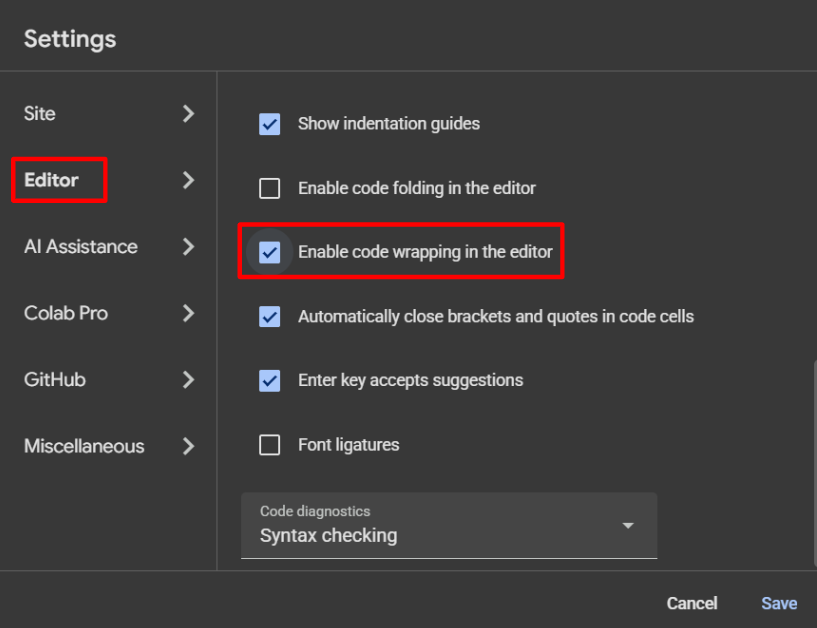

(Optional) — Run the code below to enable text wrapping in the output block for better readability.

In [1]:
from IPython.display import HTML, display, Image

def set_css():
  display(HTML('''
  <style>
    pre {
        white-space: pre-wrap;
    }
  </style>
  '''))
get_ipython().events.register('pre_run_cell', set_css)

In [2]:
%%capture
!pip -q install langchain-core langchain-community langgraph

- Set API Key and the model

### Approach 1: Gemini

In [ ]:
# %%capture
# !pip install -qU langchain-google-genai

Request for Google API KEY here : https://aistudio.google.com/app/apikey

In [ ]:
# from getpass import getpass
# import os

# if "GOOGLE_API_KEY" not in os.environ:
#     os.environ["GOOGLE_API_KEY"] = getpass("Enter your Google AI API key: ")

In [ ]:
# from langchain_google_genai import ChatGoogleGenerativeAI

# llm = ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash",
#     temperature=0,
#     max_tokens=None,
#     timeout=None,
#     max_retries=2,
#     # other params...
# )

### Approach 2: Groq API


However, we still have an **alternative** that can be used via a free-tier API: **Groq API** (compatible with LangChain). This does not require linking a credit card and offers several models, such as:

Available models: https://console.groq.com/settings/limits

👉 You can sign up and get your API Key here: [https://console.groq.com/keys](https://console.groq.com/keys)


In [3]:
!pip install -qU langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.8 MB/s eta 0:00:00


In [5]:
import getpass
import os

os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


In [6]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="qwen/qwen3.6-27b",
    reasoning_effort="none",
    max_tokens=300,
    timeout=None,
    max_retries=2,
)

# Basic LangGraph
When using LangGraph, we mainly think about five core components:

1. Node – the logic or processor
2. Entry Point – the starting point (which node the process begins with)
3. Edge – the connection between nodes, representing the workflow
4. State
   - the data structure that is passed between nodes
   - may or may not collect historical memory (Stateful vs. Stateless)
5. Condition (Conditional Edge) – determines whether the process should end or continue


## Ex.1 Hello Graph — single node

Task: Take input text and say hello to it

- Entry Point: input starts at node **echo**
- Node: only one processor (**echo**) → adds “Hello” to the input
- Condition: none → No Conditional Edge
- Edge:
  - Direct: echo → END (finish immediately)
- State: {"text": ...}
  - carries only one field
  - no memory (stateless) → each node overwrites the state

In [7]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

# ----- State -----
class EchoState(TypedDict):
    text: str

# ----- Single node: just transforms the text -----
def echo(state: EchoState):
    return {"text": f"Hello, {state['text']}!"} # return state {..}

# ----- Build the graph -----
g1 = StateGraph(EchoState)
g1.add_node("echo", echo)
g1.set_entry_point("echo")
g1.add_edge("echo", END)
app1 = g1.compile()


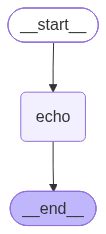

In [8]:

Image(app1.get_graph().draw_mermaid_png(max_retries=10))

In [9]:
# ----- Run -----
print(app1.invoke({"text": "LangGraph beginner"})) # latest state is printed out

{'text': 'Hello, LangGraph beginner!'}


## Ex.2 Two Nodes

Task: Transform input text by first adding a prefix, then a suffix

- Node:
  - Node A: add a prefix to the input text
  - Node B: add a suffix to the result from Node A
- Entry Point: input starts at **Node A**
- Condition: none → No conditional edge
- Edge:
  - Direct: A → B → END (straight line)
- State:
  - Node A writes `text` → updates state
  - Node B reads `text` from state (output of Node A) → processes → overwrites state
- Flow: always goes A → B

In [10]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

# ----- State -----
class ABState(TypedDict):
    text: str  # overwrite, not append (no historical memory)

# ----- Node -----
def node_a(state: ABState): # node A can access ABstate
    # Add prefix
    return {"text": f"[prefix added] {state['text']}"} # return state {..}

def node_b(state: ABState): # node B can access ABstate
    # Add suffix
    return {"text": state["text"] + " [suffix added]"} # return state {..}

# ABstate is shared across node_a and node_b.


g2 = StateGraph(ABState)
g2.add_node("A", node_a)
g2.add_node("B", node_b)

g2.set_entry_point("A")     # start at A
g2.add_edge("A", "B")       # then go to B
g2.add_edge("B", END)       # end after B
app2 = g2.compile()

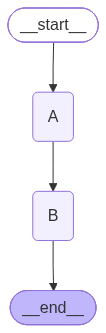

In [11]:
Image(app2.get_graph().draw_mermaid_png(max_retries=10))

In [12]:
print(app2.invoke({"text": "input text"}))

{'text': '[prefix added] input text [suffix added]'}


## Ex.3 State Updates: Overwrite vs. Accumulate


Up to this point, each node update **overwrites** the previous value:
```python
class State(TypedDict):
    text: str
```
By default, LangGraph replaces the existing value when a node returns a new value for the same state field.

If we want to **accumulate** values instead, we can define a reducer using `Annotated`:
```python
class State(TypedDict):
    text: Annotated[List[str], add]
```

A **reducer** defines how LangGraph combines the existing state value with a new update. Here, add acts as the reducer, so each new list is added to the existing list instead of replacing it.

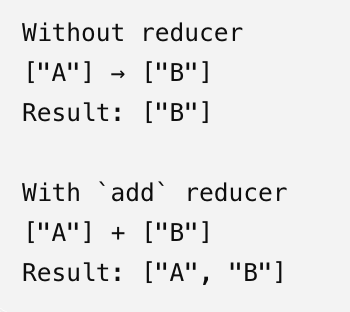

> **Important:** Accumulating values inside a graph run is not the same as persistent memory across multiple runs. Persistent state will be introduced later with **checkpointing**.


**Overwrite Example**


In [13]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

class StateLess(TypedDict):
    text: str  # here

def nodeA(state: StateLess):
    return {"text": "I am node A."} # return state {..}

def nodeB(state: StateLess):
    return {"text": "I am node B."} # return state {..}

def final(state: StateLess):
    return {"text": f"Final state: {state['text']}"} # return state {..}

g31 = StateGraph(StateLess)
g31.set_entry_point("A")
g31.add_node("A", nodeA)
g31.add_node("B", nodeB)
g31.add_node("final", final)

g31.add_edge("A", "B")
g31.add_edge("B", "final")
g31.add_edge("final", END)

app_stateless = g31.compile()

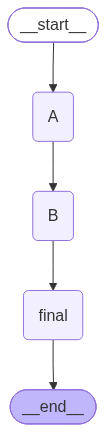

In [14]:
Image(app_stateless.get_graph().draw_mermaid_png(max_retries=10))

In [15]:
print(app_stateless.invoke({"text": ""})["text"])

Final state: I am node B.


> The value from Node A is overwritten by Node B, so only the latest value is preserved.


**Accumulate (`Add` Reducer) Example**


In [16]:
from typing import TypedDict, List, Annotated
from langgraph.graph import StateGraph, END
from operator import add

class StateFul(TypedDict):
    text: Annotated[List[str], add]  # here : automatically appends new state/ not overwrite

def nodeA(state: StateFul):
    return {"text": ["I am node A."]} # return state {..}

def nodeB(state: StateFul):
    return {"text": ["I am node B."]} # return state {..}

def final(state: StateFul):
    return {"text": [f"Final state: {state['text']}"]} # return state {..}

g32 = StateGraph(StateFul)
g32.set_entry_point("A")
g32.add_node("A", nodeA)
g32.add_node("B", nodeB)
g32.add_node("final", final)

g32.add_edge("A", "B")
g32.add_edge("B", "final")
g32.add_edge("final", END)

app_stateful = g32.compile()

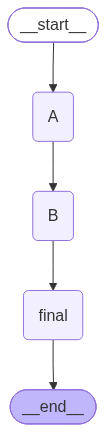

In [17]:
Image(app_stateful.get_graph().draw_mermaid_png(max_retries=10))

In [18]:
print(app_stateful.invoke({"text": []})["text"][-1]) # latest state contains all previous states (stateful)

Final state: ['I am node A.', 'I am node B.']


> With the `add` reducer, each node update is accumulated in the list instead of overwriting the previous value.


## Ex.4 Condition (Router)

Task: Build an AI that answers questions, but does not answer political ones

Nodes:
  - LLM Classifier
  - Rule-based Answer (for political question)
  - LLM Answer (for non-polical question)

Entry Point: LLM Classifier

Edges:
  - Conditional Edge (Router):
    - if `is_politic = true`:
        Router → Rule-based Answer
    - if `is_politic = false`:
        Router → LLM Answer
  - Direct Edge:
    - Rule-based Answer → END
    - LLM Answer → END

State: Stateless (no in-memory history required)


In [19]:
# Define LLMs (Groq)

llm_moderator = ChatGroq(
    model="qwen/qwen3.6-27b",
    reasoning_effort="none",
    temperature=0.2,
    max_tokens=300,
    timeout=None,
    max_retries=2,
)


llm_answer = ChatGroq(
    model="qwen/qwen3.6-27b",
    reasoning_effort="none",
    temperature=1,
    max_tokens=300,
    timeout=None,
    max_retries=2,
)

# Or Define LLMs (Gemini)
# llm_moderator = ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash",
#     temperature=0.2,
#     max_tokens=None,
#     timeout=None,
#     max_retries=2,
# )

# llm_answer = ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash",
#     temperature=1.2,
#     max_tokens=None,
#     timeout=None,
#     max_retries=2,
# )

In [20]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, END

# Define State
class BlockState(TypedDict):
    text: str        # user input, stateless
    is_politic: bool # classifier output

# Define Nodes
def classifier_node(state: BlockState):
    """
    Use the moderator LLM to classify whether the input text is political or not.
    Update 'is_politic' in the state.
    """
    user_text = state["text"]
    sys_prompt = (
        "You are a strict text classifier. "
        "Task: Decide if the user's text is about POLITICS (governments, elections, public policy, "
        "political parties, politicians, geopolitics). "
        "Reply with exactly one token: TRUE or FALSE."
    )
    msg = f"Text: {user_text}\nAnswer (TRUE/FALSE only):"
    out = llm_moderator.invoke(
        [{"role": "system", "content": sys_prompt},
         {"role": "user", "content": msg}]
    ).content.strip().upper()

    is_politic = out.startswith("T")  # TRUE -> political
    return {"is_politic": is_politic}

def llm_answer_node(state: BlockState):
    """
    If not political → generate an answer using the answering LLM.
    """
    prompt = f"Answer the user's question/help politely and concisely:\n\nUSER: {state['text']}"
    ans = llm_answer.invoke(prompt).content
    return {"text": ans}

def block_rule_node(state: BlockState):
    """
    If political → return a rule-based block message.
    """
    blocked_msg = (
        "Sorry, this content is related to politics, so I cannot provide an answer here. "
        "Please adjust your question to be non-political and try again."
    )
    return {"text": blocked_msg}

# Router (Conditional Function)
def should_allow_or_block(state: BlockState) -> Literal["allow", "block"]:
    return "block" if state.get("is_politic", False) else "allow"

# Build Graph
g = StateGraph(BlockState)
g.set_entry_point("classifier")
g.add_node("classifier", classifier_node)
g.add_node("llm_answer", llm_answer_node)
g.add_node("block_rule", block_rule_node)

g.add_conditional_edges(
    "classifier",
    should_allow_or_block,
    {
        "allow": "llm_answer",  # not political → answer with LLM (defined as `allow` path)
        "block": "block_rule",  # political → block with rule-based reply (defined as `block` path)
    },
)

g.add_edge("llm_answer", END)
g.add_edge("block_rule", END)

app_llm_no_political_talking = g.compile()

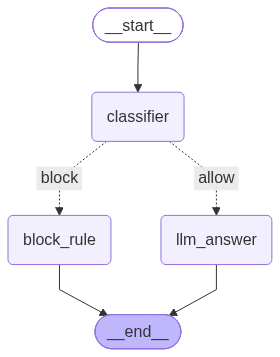

In [21]:
Image(app_llm_no_political_talking.get_graph().draw_mermaid_png(max_retries=10))

In [22]:
input = {"text": "Who will win the next election in Thailand?"}
print(f"User's query: {input}")
print('--'*40)
for state in app_llm_no_political_talking.stream(input, stream_mode="updates"):
    for node, update in state.items():
      print(f"['Node : '{node}] -> 'Result : '{update}")

User's query: {'text': 'Who will win the next election in Thailand?'}
--------------------------------------------------------------------------------
['Node : 'classifier] -> 'Result : '{'is_politic': True}
['Node : 'block_rule] -> 'Result : '{'text': 'Sorry, this content is related to politics, so I cannot provide an answer here. Please adjust your question to be non-political and try again.'}


In [23]:
input = {"text": "How does photosynthesis work?"}
print(f"User's query: {input}")
print('--'*40)
for state in app_llm_no_political_talking.stream(input, stream_mode="updates"):
    for node, update in state.items():
      print(f"['Node : '{node}] -> 'Result : '{update}")

User's query: {'text': 'How does photosynthesis work?'}
--------------------------------------------------------------------------------
['Node : 'classifier] -> 'Result : '{'is_politic': False}
['Node : 'llm_answer] -> 'Result : '{'text': "Photosynthesis is the process by which plants convert sunlight into energy. Here’s how it works in simple steps:\n\n1. **Light Absorption**: Chlorophyll in the plant's leaves absorbs sunlight.\n2. **Water Uptake**: Roots absorb water from the soil, which travels up to the leaves.\n3. **Carbon Dioxide Intake**: Leaves take in carbon dioxide from the air through tiny pores called stomata.\n4. **Chemical Reaction**: Using sunlight energy, the plant converts water and carbon dioxide into glucose (sugar) for food.\n5. **Oxygen Release**: Oxygen is produced as a byproduct and released into the air.\n\nIn short:\n**Sunlight + Water + Carbon Dioxide → Glucose + Oxygen**\n\nThis process provides energy for the plant and supplies oxygen for other living organ

## Ex.5 Cyclic Workflow (Loop)

Task: Start from a weak initial explanation, evaluate its quality, and iteratively revise it based on feedback until it is good enough.

Nodes:
- **Generate** → creates the first answer
- **Evaluate** → checks whether the answer is detailed enough
- **Revise** → improves the answer when needed

Conditional Edge:
- if the answer passes → `END`
- if the answer does not pass → `Revise → Evaluate`

This example demonstrates one of the key differences between a linear LCEL pipeline and LangGraph: **a graph can loop back to an earlier node.**


In [24]:
from typing import TypedDict, Literal, Annotated
from operator import add
from langgraph.graph import StateGraph, START, END


class ReflectionState(TypedDict):
    draft: str
    score: int
    feedback: str
    attempts: int
    history: Annotated[list, add]


def evaluate_node(state: ReflectionState):
    prompt = f"""
You are a strict but fair evaluator.

Evaluate the following explanation from 1-10.

Criteria:
- Clarity
- Specificity
- Completeness
- Usefulness

Explanation:
{state["draft"]}

Return ONLY valid JSON:

{{
    "score": 1,
    "feedback": "Specific and actionable feedback"
}}
"""

    response = llm.invoke(prompt)

    import json

    result = json.loads(
        response.content
        .replace("```json", "")
        .replace("```", "")
        .strip()
    )

    score = result["score"]
    feedback = result["feedback"]

    return {
        "score": score,
        "feedback": feedback,
        "history": [{
            "attempt": state["attempts"],
            "draft": state["draft"],
            "score": score,
            "feedback": feedback,
        }]
    }


def revise_node(state: ReflectionState):
    prompt = f"""
Improve the explanation below based on the evaluator feedback.

Current explanation:
{state["draft"]}

Evaluator feedback:
{state["feedback"]}

Improve:
- clarity
- specificity
- completeness
- usefulness

Keep the original meaning, but make the explanation more informative
and easier to understand.

Return only the improved explanation.
"""

    response = llm.invoke(prompt)

    return {
        "draft": response.content,
        "attempts": state["attempts"] + 1,
    }


def should_continue(
    state: ReflectionState
) -> Literal["finish", "revise"]:

    # Stop when quality is good enough
    if state["score"] >= 8:
        return "finish"

    # Safety stop
    if state["attempts"] >= 3:
        return "finish"

    return "revise"


g5 = StateGraph(ReflectionState)

g5.add_node("evaluate", evaluate_node)
g5.add_node("revise", revise_node)

g5.add_edge(START, "evaluate")

g5.add_conditional_edges(
    "evaluate",
    should_continue,
    {
        "finish": END,
        "revise": "revise",
    },
)

g5.add_edge("revise", "evaluate")

app_loop = g5.compile()

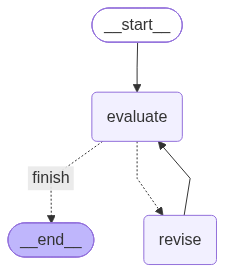

In [25]:
Image(app_loop.get_graph().draw_mermaid_png(max_retries=10))


In [26]:
initial_state = {
    "draft": """
Machine learning is when computers learn things from data.
It is useful because computers can do many tasks better.
""",
    "score": 0,
    "feedback": "",
    "attempts": 1,
    "history": [],
}

for event in app_loop.stream(initial_state):

    if "evaluate" in event:
        step = event["evaluate"]["history"][0]

        print("=" * 70)
        print(f"ITERATION {step['attempt']}")
        print("=" * 70)

        print("\nDraft:\n")
        print(step["draft"])

        print(f"\nScore: {step['score']} / 10")

        print("\nFeedback:\n")
        print(step["feedback"])

        print()

ITERATION 1

Draft:


Machine learning is when computers learn things from data.
It is useful because computers can do many tasks better.


Score: 2 / 10

Feedback:

The explanation is extremely vague and lacks technical substance. 'Computers learn things' is a colloquialism that fails to define the mechanism (e.g., pattern recognition, model training, optimization). The claim that computers do tasks 'better' is imprecise; they do certain data-intensive or pattern-based tasks more efficiently or accurately than humans, but not all tasks. To improve, specify that machine learning involves algorithms improving performance on a specific task through experience (data) without being explicitly programmed for every rule, and provide concrete examples of applications (e.g., image recognition, recommendation systems) to demonstrate utility.

ITERATION 2

Draft:

Machine learning is a branch of artificial intelligence where algorithms improve their performance on a specific task through experie

> **Key idea:** The `evaluate` node can route execution either to `END` or back to `revise`. This creates a **cycle**, which is useful for reflection, retry, validation, and iterative improvement workflows.


## Ex.6 Persistent State with Checkpointing

The previous examples manage state **within one graph execution**. If we want the graph to remember information across multiple calls, we can add a **checkpointer**.

For conversational workflows, LangGraph commonly uses `MessagesState`, which stores a sequence of chat messages.

- `MessagesState` → manages conversation messages in the graph state
- `InMemorySaver` → stores checkpoints in memory
- `thread_id` → identifies which conversation/state history should be continued

> For production systems, a persistent database-backed checkpointer is typically used instead of in-memory storage.


In [27]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver


def chatbot_node(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}


g6 = StateGraph(MessagesState)
g6.add_node("chatbot", chatbot_node)
g6.add_edge(START, "chatbot")
g6.add_edge("chatbot", END)

checkpointer = InMemorySaver()
app_memory = g6.compile(checkpointer=checkpointer)


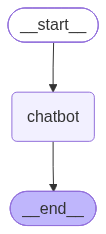

In [28]:
Image(app_memory.get_graph().draw_mermaid_png(max_retries=10))


**Turn 1**

In [29]:
# Same thread_id = same conversation history
config = {"configurable": {"thread_id": "student-demo"}}

response1 = app_memory.invoke(
    {"messages": [{"role": "user", "content": "Hello, my name is Alice."}]},
    config=config,
)
print(response1["messages"][-1].content)

Hello Alice! It's nice to meet you. How can I help you today?


**Turn 2**

In [30]:
# Same thread_id = same conversation history
config = {"configurable": {"thread_id": "student-demo"}}

response1 = app_memory.invoke(
    {"messages": [{"role": "user", "content": "My favorite programming language is Python."}]},
    config=config,
)
print(response1["messages"][-1].content)

That's a great choice! Python is incredibly versatile and has a huge community. Whether you're into data science, web development, automation, or just learning the basics, it's a powerful tool.

Are you currently working on any specific projects, or are you looking for help with something in particular?


**Turn 3: Recall Previous Information**

In [31]:
response2 = app_memory.invoke(
    {"messages": [{"role": "user", "content": "What is my name and what is my favorite programming language?"}]},
    config=config,
)
print(response2["messages"][-1].content)

Your name is Alice, and your favorite programming language is Python.


> **State vs. Checkpointing**
>
> - **State** describes the data that flows through nodes during execution.
> - **Reducers** define how state updates are merged.
> - **Checkpointing** persists graph state so that later runs can continue from previous context.


## Ex.7 Tool-Calling Agent Loop

In the LangChain notebook, tool calling can be executed manually. LangGraph can turn the same idea into an **agent loop**:

`LLM → Tool decision → ToolNode → LLM → ... → END`

Here,** the model decides whether a tool is needed.** If a tool call is generated, `ToolNode` executes it and returns the result to the model. The loop continues until the model produces a normal answer.


In [32]:
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition


@tool
def multiply(a: int, b: int) -> int:
    """Multiply two integers."""
    return a * b


tools = [multiply]
llm_with_tools = llm.bind_tools(tools)


def assistant_node(state: MessagesState):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


g7 = StateGraph(MessagesState)
g7.add_node("assistant", assistant_node)
g7.add_node("tools", ToolNode(tools))

g7.add_edge(START, "assistant")
g7.add_conditional_edges(
    "assistant",
    tools_condition,
)
g7.add_edge("tools", "assistant")

app_agent = g7.compile()


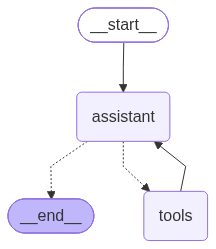

In [33]:
Image(app_agent.get_graph().draw_mermaid_png(max_retries=10))


In [34]:
for state in app_agent.stream(
    {"messages": [{"role": "user", "content": "What is 23 multiplied by 17?"}]},
    stream_mode="updates",
):
    for node, update in state.items():
        print(f"Node: {node}")
        if "messages" in update:
            print(update["messages"][-1])
        print("-" * 60)


Node: assistant
content='' additional_kwargs={'tool_calls': [{'id': 'zbpcjd6n1', 'function': {'arguments': '{"a":23,"b":17}', 'name': 'multiply'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 289, 'total_tokens': 327, 'completion_time': 0.087946753, 'completion_tokens_details': None, 'prompt_time': 0.024763491, 'prompt_tokens_details': None, 'queue_time': 0.226567915, 'total_time': 0.112710244}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_56b71ffadd', 'service_tier': 'on_demand', 'reasoning_effort': 'none', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a08ee8-c411-7ab3-a2af-176880521eb4-0' tool_calls=[{'name': 'multiply', 'args': {'a': 23, 'b': 17}, 'id': 'zbpcjd6n1', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 289, 'output_tokens': 38, 'total_tokens': 327}
------------------------------------------------------------
Node: tools
content='391' 

> **Key idea:** Tool calling tells us *which tool the model wants to use*. LangGraph manages the **execution loop** around that decision: call the tool, return the result to the model, and continue until no more tool calls are required.


## Summary

After these examples, the core LangGraph concepts are:

1. **State** — data shared across nodes
2. **Nodes** — functions that read and update state
3. **Edges** — define execution flow
4. **Conditional Edges** — route execution based on state
5. **Reducers** — control how state updates are merged
6. **Cycles / Loops** — revisit nodes for iterative workflows
7. **Checkpointing** — persist state across runs
8. **ToolNode / Agent Loop** — execute model-selected tools inside the graph

These concepts provide the foundation for more advanced workflows such as RAG agents, human-in-the-loop systems, and multi-agent graphs.
